In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os, sys
sys.path.insert(0, os.path.join("../.."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from PIL import Image
from sklearn.model_selection import KFold

from src.models import VisionAuxNet, VisionRegNet
from src.gradcam_saliency import GradCAMSwin, cam_to_heatmap, compute_cam_mask_overlap
from src.data import build_transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
main_folder = "../.."
img_folder  = os.path.join(main_folder, "data", "train")

/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Paths to model checkpoints and other constants for visualization and CAM analysis.
BASELINE_DIR = os.path.join(main_folder, "outputs", "extra",
               "exp3_swin_384_strong_MSE_MLPHead")
BRISQUE_DIR  = os.path.join(main_folder, "outputs", "extra",
               "exp15_swin_384_strong_MSE_aux_brisque_normalized_fixNormLeakage_brisque_strongHead")
VIS_DIR      = os.path.join(main_folder, "outputs", "extra",
               "exp15_swin_384_strong_MSE_aux_visibility_normalized_MLP_Head")   
SAL_DIR      = os.path.join(main_folder, "outputs", "extra",
               "exp16_swin_384_strong_MSELoss_saliency_strongHead")

BACKBONE  = "swin_large_patch4_window12_384"
IMG_SIZE  = 384
SWIN_GRID = (12, 12)

In [ ]:
#Model loading 
def load_baseline(fold, device):
    model = VisionRegNet(
        backbone_name=BACKBONE, img_size=IMG_SIZE,
        head_type="mlp", pretrained=False,
    ).to(device)
    model.load_state_dict(torch.load(
        os.path.join(BASELINE_DIR, f"model_fold{fold}.pt"), map_location=device))
    model.eval()
    return model

def load_brisque_model(fold, device):
    model = VisionAuxNet(
        backbone_name=BACKBONE, img_size=IMG_SIZE,
        aux_tasks=["brisque"], head_type="mlp",
        pretrained=False, use_saliency=False,
    ).to(device)
    model.load_state_dict(torch.load(
        os.path.join(BRISQUE_DIR, f"model_fold{fold}.pt"), map_location=device))
    model.eval()
    return model

def load_vis_model(fold, device):
    model = VisionAuxNet(
        backbone_name=BACKBONE, img_size=IMG_SIZE,
        aux_tasks=["visibility_ratio"], head_type="mlp",
        pretrained=False, use_saliency=False,
    ).to(device)
    model.load_state_dict(torch.load(
        os.path.join(VIS_DIR, f"model_fold{fold}.pt"), map_location=device))
    model.eval()
    return model

def load_saliency_model(fold, device):
    model = VisionAuxNet(
        backbone_name=BACKBONE,
        img_size=IMG_SIZE,
        aux_tasks=[],           # saliency-only, no aux prediction head
        head_type="mlp",
        pretrained=False,
        use_saliency=False,     # no hook needed for inference
    ).to(device)
    ckpt = os.path.join(SAL_DIR, f"model_fold{fold}.pt")
    model.load_state_dict(torch.load(ckpt, map_location=device))
    model.eval()
    return model

def get_target_layer_baseline(model):
    if hasattr(model, "model"):
        return model.model.layers[-1].blocks[-1].norm1
    elif hasattr(model, "backbone"):
        return model.backbone.layers[-1].blocks[-1].norm1
    raise AttributeError("Could not find Swin backbone")

def get_target_layer_aux(model):
    return model.backbone.layers[-1].blocks[-1].norm1

val_tf = build_transforms(IMG_SIZE, "strong", train=False)

def preprocess(img_path):
    img = Image.open(img_path).convert("RGB")
    return val_tf(img).unsqueeze(0), img

In [20]:
from ultralytics import YOLO 

In [ ]:
def make_face_proxy_bbox(bbox, img_w, img_h,
                         x_frac=(0.25, 0.75), y_frac=(0.00, 0.45)):
    """
    Heuristic face region proxy inside the YOLO pet bounding box.
    , the face region is approximated as the upper-center portion of the pet bbox:
      - horizontal: middle 50% of pet bbox width  (25% to 75%)
      - vertical:   top 45% of pet bbox height     (0%  to 45%)
    This assumes the pet face is roughly in the upper-center of its body.
    Works reasonably for upright frontal pets; less accurate for lying/turned pets.
    TODO: replace with a real pet face detector (e.g. YOLOv8 pet face) in future.
    """
    x1, y1, x2, y2 = [float(v) for v in bbox]
    bw = max(0.0, x2 - x1)  # pet bbox width
    bh = max(0.0, y2 - y1)  # pet bbox height
    # compute face proxy coords as fractions of pet bbox, clipped to image bounds
    fx1 = int(max(0, min(img_w, x1 + x_frac[0] * bw)))
    fx2 = int(max(0, min(img_w, x1 + x_frac[1] * bw)))
    fy1 = int(max(0, min(img_h, y1 + y_frac[0] * bh)))
    fy2 = int(max(0, min(img_h, y1 + y_frac[1] * bh)))
    return (fx1, fy1, fx2, fy2)


def draw_bboxes_on_image(img_pil, pet_bbox, face_bbox=None,
                         pet_color=(0, 255, 0), face_color=(255, 0, 0)):
    """
    Draw pet bbox (green) and optional face bbox (red) on image.
    Draws only the rectangle border as 2px thick lines, not a filled box.
    Returns a new PIL Image with boxes drawn.
    """
    img_np = np.array(img_pil.convert("RGB")).copy()
    img_h, img_w = img_np.shape[:2]

    # clip and draw pet bbox (green)
    x1, y1, x2, y2 = [int(v) for v in pet_bbox]
    x1 = max(0, min(img_w-1, x1)); x2 = max(0, min(img_w-1, x2))
    y1 = max(0, min(img_h-1, y1)); y2 = max(0, min(img_h-1, y2))
    img_np[y1:y2, x1:x1+2] = pet_color   # left edge
    img_np[y1:y2, x2-2:x2] = pet_color   # right edge
    img_np[y1:y1+2, x1:x2] = pet_color   # top edge
    img_np[y2-2:y2, x1:x2] = pet_color   # bottom edge

    if face_bbox is not None:
        # clip and draw face bbox (red)
        fx1, fy1, fx2, fy2 = [int(v) for v in face_bbox]
        fx1 = max(0, min(img_w-1, fx1)); fx2 = max(0, min(img_w-1, fx2))
        fy1 = max(0, min(img_h-1, fy1)); fy2 = max(0, min(img_h-1, fy2))
        img_np[fy1:fy2, fx1:fx1+2] = face_color   # left edge
        img_np[fy1:fy2, fx2-2:fx2] = face_color   # right edge
        img_np[fy1:fy1+2, fx1:fx2] = face_color   # top edge
        img_np[fy2-2:fy2, fx1:fx2] = face_color   # bottom edge

    return Image.fromarray(img_np)


def predict_scores(model, img_tensor, aux_key=None, scale_target=False):
    """
    Run inference and return Pawpularity prediction and optional aux prediction.
    Works for both model types:
      VisionRegNet : returns plain tensor  (main_pred, None)
      VisionAuxNet : returns dict          (main_pred, aux_pred)
    scale_target=True  : apply sigmoid * 100 (BCE-trained models)
    scale_target=False : use raw output      (MSE-trained models, default)
    """
    model.eval()
    with torch.no_grad():
        out = model(img_tensor.to(device))
        if isinstance(out, dict):
            main_pred = out["main"]
            if scale_target:
                main_pred = torch.sigmoid(main_pred) * 100.0
            main_val = float(main_pred.squeeze().cpu().item())
            # return aux prediction only if key exists in model output
            aux_val  = float(out[aux_key].squeeze().cpu().item()) \
                       if aux_key and aux_key in out else None
            return main_val, aux_val
        else:
            pred = out
            if scale_target:
                pred = torch.sigmoid(pred) * 100.0
            return float(pred.squeeze().cpu().item()), None

In [6]:
df = pd.read_csv(os.path.join(main_folder, "data", "train_brisque_visibility_ratio.csv"))
df_detected = df[df["yolo_conf"] > 0.3].reset_index(drop=True)
print(f"Images with YOLO detection: {len(df_detected)} / {len(df)}")

Images with YOLO detection: 9437 / 9912


In [ ]:

#  Split dataset into 5 folds ─
# Same KFold split used during training (same seed=42) so val_idx matches
# exactly the images each fold's model never saw during training
kf      = KFold(n_splits=5, shuffle=True, random_state=42)
results = []

for fold, (tr_idx, val_idx) in enumerate(kf.split(df), start=1):

    # take only this fold's validation images
    val_df       = df.iloc[val_idx].reset_index(drop=True)
    # keep only images where YOLO detected a pet (conf > 0.3)
    # we need a valid pet bbox to compute CAM overlap
    val_detected = val_df[val_df["yolo_conf"] > 0.3].reset_index(drop=True)
    print(f"\nFold {fold} | val detected: {len(val_detected)}")

    #  load the fold-specific checkpoint for each model 
    # each fold has its own trained weights → use the matching checkpoint
    model_base = load_baseline(fold, device)
    model_bri  = load_brisque_model(fold, device)
    model_vis  = load_vis_model(fold, device)
    model_sal  = load_saliency_model(fold, device)

    #  create GradCAM objects for each model 
    # registers forward and backward hooks on the target layer
    # grid_size=(12,12) tells GradCAM the final feature map is 12×12
    cam_base = GradCAMSwin(model_base, get_target_layer_baseline(model_base),
                           device, grid_size=SWIN_GRID)
    cam_bri  = GradCAMSwin(model_bri, get_target_layer_aux(model_bri),
                           device, grid_size=SWIN_GRID)
    cam_vis  = GradCAMSwin(model_vis, get_target_layer_aux(model_vis),
                           device, grid_size=SWIN_GRID)
    cam_sal  = GradCAMSwin(model_sal, get_target_layer_aux(model_sal),
                           device, grid_size=SWIN_GRID)

    #  per-image overlap accumulators 
    pet_base, pet_bri, pet_vis, pet_sal     = [], [], [], []
    face_base, face_bri, face_vis, face_sal = [], [], [], []
    n_skip = 0

    #  process every detected validation image 
    for _, row in val_detected.iterrows():
        path = os.path.join(img_folder, row["Id"] + ".jpg")
        img_tensor, img_pil = preprocess(path)
        W, H = img_pil.size

        # pet bbox from YOLO (used for CAM–pet overlap)
        bbox      = (row["bbox_x1"], row["bbox_y1"], row["bbox_x2"], row["bbox_y2"])
        # face proxy: upper-center of pet bbox (used for CAM–face overlap)
        face_bbox = make_face_proxy_bbox(bbox, W, H)

        try:
            #  compute GradCAM and overlap for all 4 models 
            # iterate over (cam_object, pet_overlap_list, face_overlap_list)
            for cam_obj, pet_list, face_list in [
                (cam_base, pet_base, face_base),
                (cam_bri,  pet_bri,  face_bri),
                (cam_vis,  pet_vis,  face_vis),
                (cam_sal,  pet_sal,  face_sal),
            ]:
                # run GradCAM: forward + backward pass → spatial heatmap
                c = cam_obj(img_tensor)
                # resize heatmap from 12×12 to original image resolution
                _, cam_rsz = cam_to_heatmap(c, img_pil)
                # compute IoU between top-50% CAM region and pet bbox
                pet_list.append(compute_cam_mask_overlap(cam_rsz, bbox, W, H))
                # compute IoU between top-50% CAM region and face proxy bbox
                face_list.append(compute_cam_mask_overlap(cam_rsz, face_bbox, W, H))

        except Exception as e:
            # skip images that fail (e.g. corrupted file, hook error)
            # these are edge cases and do not affect the overall statistics
            n_skip += 1
            if n_skip <= 5:
                print(f"  Skipping {row['Id']}: {e}")
            elif n_skip == 6:
                print("  ... (further skip messages suppressed)")
            continue

    #  remove hooks after each fold to free memory ─
    cam_base.remove_hooks()
    cam_bri.remove_hooks()
    cam_vis.remove_hooks()
    cam_sal.remove_hooks()

    if len(pet_base) == 0:
        print(f"  Fold {fold}: NO valid overlaps computed.")
        continue

    #  print per-fold summary 
    print(f"  Processed {len(pet_base)} / {len(val_detected)} (skipped {n_skip})")
    print(f"  Pet  overlap — base: {np.mean(pet_base):.4f} | "
          f"brisque: {np.mean(pet_bri):.4f} | "
          f"vis: {np.mean(pet_vis):.4f} | "
          f"sal: {np.mean(pet_sal):.4f}")
    print(f"  Face overlap — base: {np.mean(face_base):.4f} | "
          f"brisque: {np.mean(face_bri):.4f} | "
          f"vis: {np.mean(face_vis):.4f} | "
          f"sal: {np.mean(face_sal):.4f}")

    #  store per-fold results 
    # delta = aux model overlap - baseline overlap (positive = aux is better)
    results.append({
        "fold":                  fold,
        "n_images":              len(pet_base),
        "n_skipped":             n_skip,
        # mean CAM–pet overlap per model (fraction of attention inside pet bbox)
        "base_pet_overlap":      np.mean(pet_base),
        "brisque_pet_overlap":   np.mean(pet_bri),
        "vis_pet_overlap":       np.mean(pet_vis),
        "sal_pet_overlap":       np.mean(pet_sal),
        # mean CAM–face overlap per model (fraction of attention inside face proxy)
        "base_face_overlap":     np.mean(face_base),
        "brisque_face_overlap":  np.mean(face_bri),
        "vis_face_overlap":      np.mean(face_vis),
        "sal_face_overlap":      np.mean(face_sal),
        # delta: how much each aux model improves over baseline
        "pet_delta_brisque":     np.mean(pet_bri)  - np.mean(pet_base),
        "pet_delta_vis":         np.mean(pet_vis)  - np.mean(pet_base),
        "pet_delta_sal":         np.mean(pet_sal)  - np.mean(pet_base),
        "face_delta_brisque":    np.mean(face_bri) - np.mean(face_base),
        "face_delta_vis":        np.mean(face_vis) - np.mean(face_base),
        "face_delta_sal":        np.mean(face_sal) - np.mean(face_base),
    })
# skipped, means images with errors during CAM processing, e.g. due to small pet bbox or face proxy bbox leading to zero division in overlap calculation. These are likely edge cases where CAM analysis is less reliable anyway, so skipping them is reasonable for this qualitative analysis.    


Fold 1 | val detected: 1883


/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/torch/autograd/graph.py:823: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:180.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  Processed 1883 / 1883 (skipped 0)
  Pet  overlap — base: 0.0677 | brisque: 0.0766 | vis: 0.0918 | sal: 0.0472
  Face overlap — base: 0.0182 | brisque: 0.0083 | vis: 0.0229 | sal: 0.0088

Fold 2 | val detected: 1903
  Processed 1903 / 1903 (skipped 0)
  Pet  overlap — base: 0.0674 | brisque: 0.0658 | vis: 0.0666 | sal: 0.0673
  Face overlap — base: 0.0154 | brisque: 0.0242 | vis: 0.0214 | sal: 0.0222

Fold 3 | val detected: 1891
  Processed 1891 / 1891 (skipped 0)
  Pet  overlap — base: 0.0840 | brisque: 0.0631 | vis: 0.0847 | sal: 0.0859
  Face overlap — base: 0.0204 | brisque: 0.0167 | vis: 0.0205 | sal: 0.0243

Fold 4 | val detected: 1879
  Processed 1879 / 1879 (skipped 0)
  Pet  overlap — base: 0.0803 | brisque: 0.0786 | vis: 0.0974 | sal: 0.0796
  Face overlap — base: 0.0096 | brisque: 0.0208 | vis: 0.0199 | sal: 0.0125

Fold 5 | val detected: 1881
  Processed 1881 / 1881 (skipped 0)
  Pet  overlap — base: 0.0859 | brisque: 0.0973 | vis: 0.0757 | sal: 0.1186
  Face overlap — bas

In [12]:
results_df = pd.DataFrame(results)
print("\n", results_df.to_string(index=False))

print(f"\nMean pet overlap  — base: {results_df['base_pet_overlap'].mean():.4f} | "
      f"brisque: {results_df['brisque_pet_overlap'].mean():.4f} | "
      f"vis: {results_df['vis_pet_overlap'].mean():.4f} | "
      f"sal: {results_df['sal_pet_overlap'].mean():.4f}")
print(f"Mean face overlap — base: {results_df['base_face_overlap'].mean():.4f} | "
      f"brisque: {results_df['brisque_face_overlap'].mean():.4f} | "
      f"vis: {results_df['vis_face_overlap'].mean():.4f} | "
      f"sal: {results_df['sal_face_overlap'].mean():.4f}")



results_df.to_csv(os.path.join(BRISQUE_DIR, "saliency_overlap_results_all_models.csv"), index=False)


  fold  n_images  n_skipped  base_pet_overlap  brisque_pet_overlap  vis_pet_overlap  sal_pet_overlap  base_face_overlap  brisque_face_overlap  vis_face_overlap  sal_face_overlap  pet_delta_brisque  pet_delta_vis  pet_delta_sal  face_delta_brisque  face_delta_vis  face_delta_sal
    1      1883          0          0.067703             0.076578         0.091783         0.047243           0.018250              0.008269          0.022916          0.008849           0.008876       0.024080      -0.020459           -0.009981        0.004666       -0.009401
    2      1903          0          0.067408             0.065839         0.066602         0.067310           0.015390              0.024224          0.021381          0.022159          -0.001569      -0.000807      -0.000098            0.008834        0.005991        0.006770
    3      1891          0          0.084023             0.063089         0.084716         0.085948           0.020405              0.016654          0.020465      

In [ ]:
#  Print clean comparison table
print("\n=== CAM Overlap Comparison (mean across 5 folds) ===\n")
print(f"{'Model':<25} {'Pet Overlap':>12} {'Face Overlap':>13}")
print("-" * 52)
print(f"{'Swin image-only':<25} "
      f"{results_df['base_pet_overlap'].mean():>12.4f} "
      f"{results_df['base_face_overlap'].mean():>13.4f}")
print(f"{'Swin + BRISQUE aux':<25} "
      f"{results_df['brisque_pet_overlap'].mean():>12.4f} "
      f"{results_df['brisque_face_overlap'].mean():>13.4f}")
print(f"{'Swin + visibility aux':<25} "
      f"{results_df['vis_pet_overlap'].mean():>12.4f} "
      f"{results_df['vis_face_overlap'].mean():>13.4f}")
print(f"{'Swin + saliency':<25} "
      f"{results_df['sal_pet_overlap'].mean():>12.4f} "
      f"{results_df['sal_face_overlap'].mean():>13.4f}")


=== CAM Overlap Comparison (mean across 5 folds) ===

Model                      Pet Overlap  Face Overlap
----------------------------------------------------
Swin image-only                 0.0771        0.0169
Swin + BRISQUE aux              0.0763        0.0185
Swin + visibility aux           0.0832        0.0200
Swin + saliency                 0.0797        0.0169


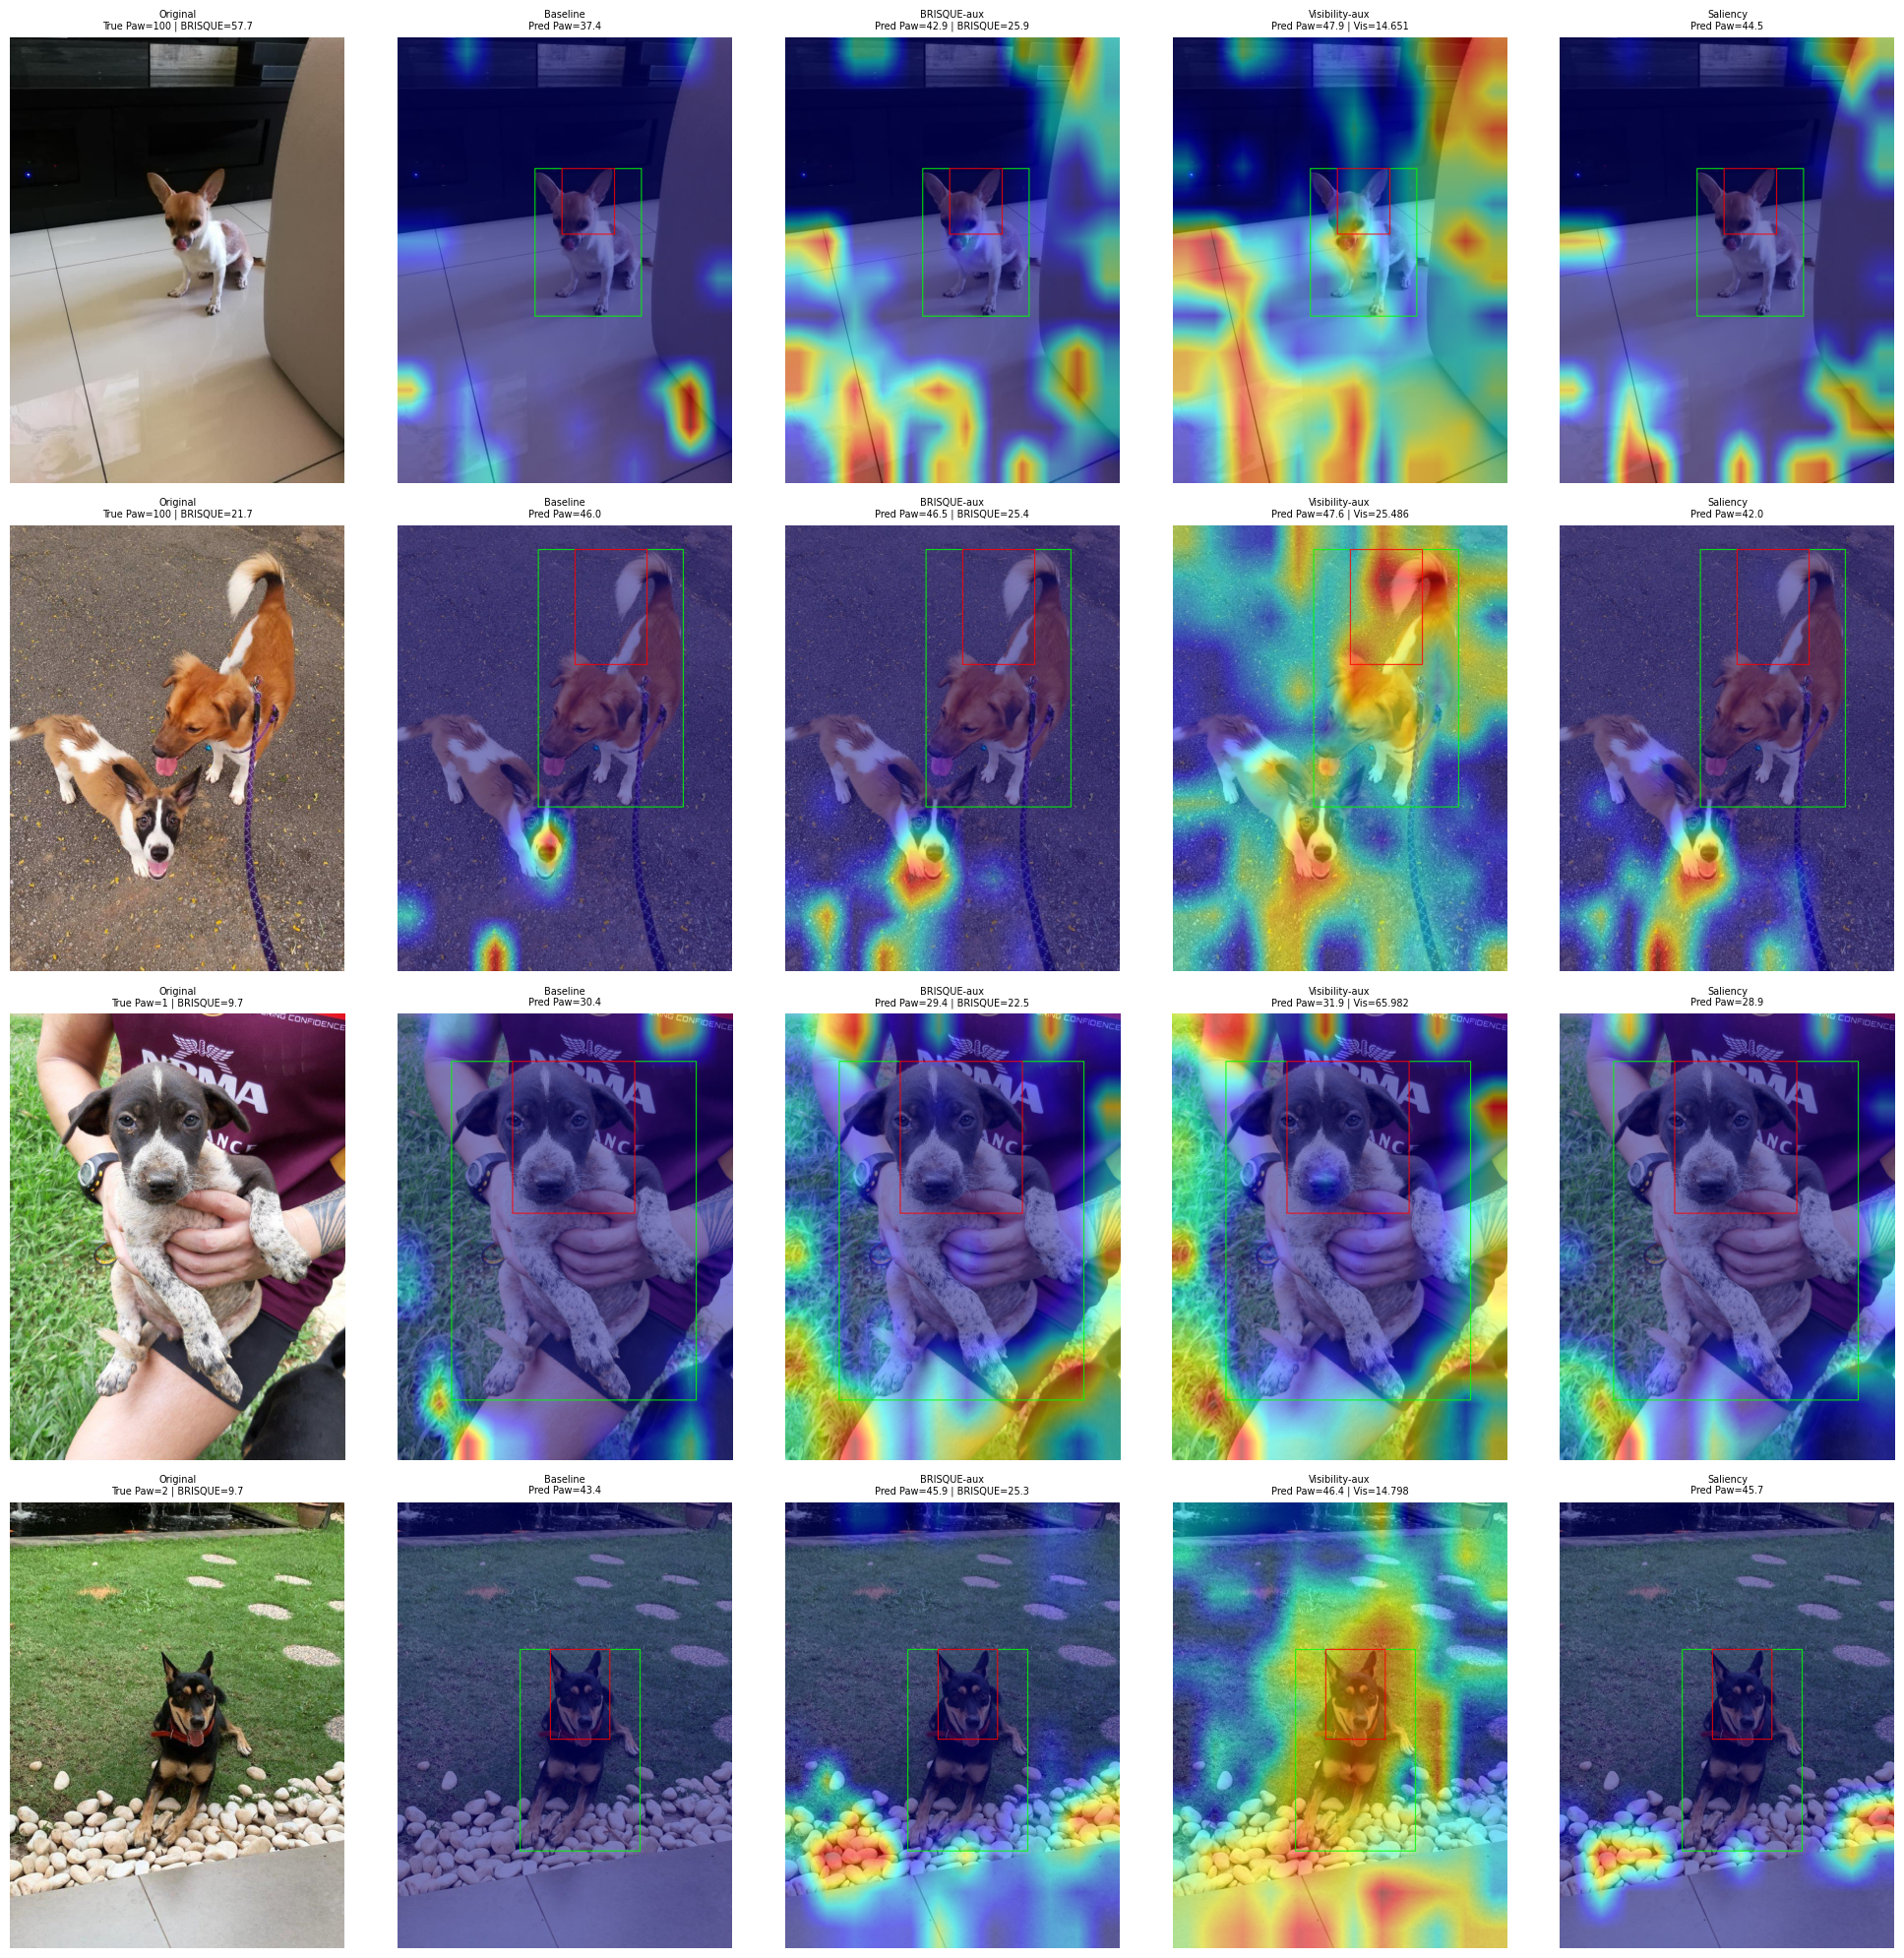

In [29]:
# Qualitative GradCAM figure — all models
# Layout: original | baseline+boxes | brisque+boxes | visibility+boxes | saliency+boxes

fold = 1
model_base = load_baseline(fold, device)
model_bri  = load_brisque_model(fold, device)
model_vis  = load_vis_model(fold, device)
model_sal  = load_saliency_model(fold, device)

cam_base = GradCAMSwin(model_base, get_target_layer_baseline(model_base),
                       device, grid_size=SWIN_GRID)
cam_bri  = GradCAMSwin(model_bri, get_target_layer_aux(model_bri),
                       device, grid_size=SWIN_GRID)
cam_vis  = GradCAMSwin(model_vis, get_target_layer_aux(model_vis),
                       device, grid_size=SWIN_GRID)
cam_sal  = GradCAMSwin(model_sal, get_target_layer_aux(model_sal),
                       device, grid_size=SWIN_GRID)

# strict: fold 1 validation images only
kf_tmp = KFold(n_splits=5, shuffle=True, random_state=42)
_, val_idx_fold1 = list(kf_tmp.split(df))[0]
val_df_fold1     = df.iloc[val_idx_fold1].reset_index(drop=True)
val_detected_fold1 = val_df_fold1[val_df_fold1["yolo_conf"] > 0.3].reset_index(drop=True)

# pick 2 high + 2 low Pawpularity from val split
sample_ids = (
    val_detected_fold1.nlargest(2, "Pawpularity")["Id"].tolist() +
    val_detected_fold1.nsmallest(2, "Pawpularity")["Id"].tolist()
)

# 5 columns: original | baseline | brisque | visibility | saliency
# pet bbox (green) and face proxy (red) drawn on all GradCAM overlays
fig, axes = plt.subplots(len(sample_ids), 5, figsize=(20, 5 * len(sample_ids)))
if len(sample_ids) == 1:
    axes = np.expand_dims(axes, axis=0)

for i, img_id in enumerate(sample_ids):
    row = df[df["Id"] == img_id].iloc[0]
    path = os.path.join(img_folder, img_id + ".jpg")

    img_pil = Image.open(path).convert("RGB")
    W, H = img_pil.size
    img_tensor, _ = preprocess(path)

    pet_bbox  = (row["bbox_x1"], row["bbox_y1"], row["bbox_x2"], row["bbox_y2"])
    face_bbox = make_face_proxy_bbox(pet_bbox, W, H)

    true_paw     = float(row["Pawpularity"])
    true_brisque = float(row["BRISQUE"]) if "BRISQUE" in row.index else None

    base_paw, _      = predict_scores(model_base, img_tensor)
    bri_paw, bri_aux = predict_scores(model_bri,  img_tensor, aux_key="brisque")
    vis_paw, vis_aux = predict_scores(model_vis,  img_tensor, aux_key="visibility_ratio")
    sal_paw, _       = predict_scores(model_sal,  img_tensor, aux_key=None)

    # compute GradCAM overlays
    overlay_base, _ = cam_to_heatmap(cam_base(img_tensor.to(device)), img_pil)
    overlay_bri,  _ = cam_to_heatmap(cam_bri(img_tensor.to(device)),  img_pil)
    overlay_vis,  _ = cam_to_heatmap(cam_vis(img_tensor.to(device)),  img_pil)
    overlay_sal,  _ = cam_to_heatmap(cam_sal(img_tensor.to(device)),  img_pil)

    # draw pet bbox (green) and face proxy (red) on each GradCAM overlay
    overlay_base_boxes = draw_bboxes_on_image(overlay_base, pet_bbox, face_bbox)
    overlay_bri_boxes  = draw_bboxes_on_image(overlay_bri,  pet_bbox, face_bbox)
    overlay_vis_boxes  = draw_bboxes_on_image(overlay_vis,  pet_bbox, face_bbox)
    overlay_sal_boxes  = draw_bboxes_on_image(overlay_sal,  pet_bbox, face_bbox)

    # col 0: original image with title info
    axes[i, 0].imshow(img_pil)
    axes[i, 0].set_title(
        f"Original\nTrue Paw={true_paw:.0f} | BRISQUE={true_brisque:.1f}",
        fontsize=7)
    axes[i, 0].axis("off")

    # col 1: baseline GradCAM + boxes
    axes[i, 1].imshow(overlay_base_boxes)
    axes[i, 1].set_title(f"Baseline\nPred Paw={base_paw:.1f}", fontsize=7)
    axes[i, 1].axis("off")

    # col 2: BRISQUE-aux GradCAM + boxes
    axes[i, 2].imshow(overlay_bri_boxes)
    axes[i, 2].set_title(
        f"BRISQUE-aux\nPred Paw={bri_paw:.1f} | BRISQUE={bri_aux:.1f}",
        fontsize=7)
    axes[i, 2].axis("off")

    # col 3: visibility-aux GradCAM + boxes
    axes[i, 3].imshow(overlay_vis_boxes)
    axes[i, 3].set_title(
        f"Visibility-aux\nPred Paw={vis_paw:.1f} | Vis={vis_aux:.3f}",
        fontsize=7)
    axes[i, 3].axis("off")

    # col 4: saliency GradCAM + boxes
    axes[i, 4].imshow(overlay_sal_boxes)
    axes[i, 4].set_title(f"Saliency\nPred Paw={sal_paw:.1f}", fontsize=7)
    axes[i, 4].axis("off")

# plt.suptitle(
#     "pet bbox (green) and face proxy (red)",
#     fontsize=9, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(BRISQUE_DIR, "saliency_qualitative_all_models.png"),
            dpi=150, bbox_inches="tight")
plt.show()

cam_base.remove_hooks()
cam_bri.remove_hooks()
cam_vis.remove_hooks()
cam_sal.remove_hooks()